<a href="https://colab.research.google.com/github/phaniraghava1234/physics_informed_neural_networks/blob/main/2D_Navier_Stokes_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
Mounted at /content/drive


In [6]:
import os
project_path = "/content/drive/MyDrive/ColabProjects/physics_informed_neural_networks"

os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)

print("Current working directory:", os.getcwd())

Current working directory: /content/drive/MyDrive/ColabProjects/physics_informed_neural_networks


In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==========================================
# 0. Device Configuration
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")


Training on device: cuda


In [7]:
# ==========================================
# 1. Exact Analytical Solution (Kovasznay Flow)
# ==========================================
def exact_kovasznay(x, y, Re=20.0):
    """Exact analytical solution for 2D Kovasznay flow."""
    lambda_val = Re / 2.0 - np.sqrt(Re**2 / 4.0 + 4 * np.pi**2)

    u = 1.0 - np.exp(lambda_val * x) * np.cos(2 * np.pi * y)
    v = (lambda_val / (2 * np.pi)) * np.exp(lambda_val * x) * np.sin(2 * np.pi * y)
    p = -0.5 * np.exp(2 * lambda_val * x)

    return u, v, p

# ==========================================
# 2. Draw Geometry & Boundary Conditions Schematic
# ==========================================
def draw_geometry():
    fig, ax = plt.subplots(figsize=(8, 6))

    # Draw Domain
    rect = patches.Rectangle((-0.5, -0.5), 1.5, 2.0, linewidth=2, edgecolor='black', facecolor='lightblue', alpha=0.3)
    ax.add_patch(rect)

    # Annotations
    ax.text(0.25, 0.5, 'Computational Domain\n(Kovasznay Flow)\n$Re = 20$',
            fontsize=14, ha='center', va='center', fontweight='bold')

    # Inlet (Left)
    ax.annotate('Inlet BC\nExact $u, v, p$', xy=(-0.5, 0.5), xytext=(-1.2, 0.5),
                arrowprops=dict(facecolor='red', shrink=0.05), fontsize=12, va='center')

    # Outlet (Right)
    ax.annotate('Outlet BC\nExact $u, v, p$', xy=(1.0, 0.5), xytext=(1.4, 0.5),
                arrowprops=dict(facecolor='blue', shrink=0.05), fontsize=12, va='center')

    # Top/Bottom
    ax.text(0.25, 1.6, 'Top BC (Exact $u, v, p$)', fontsize=12, ha='center')
    ax.text(0.25, -0.7, 'Bottom BC (Exact $u, v, p$)', fontsize=12, ha='center')

    ax.set_xlim(-1.5, 2.0)
    ax.set_ylim(-1.0, 2.0)
    ax.set_xlabel('x-axis')
    ax.set_ylabel('y-axis')
    ax.set_title('Problem 3: Geometry & Boundary Conditions')
    ax.grid(True, linestyle='--')

    plt.savefig('geometry_bc.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Geometry diagram saved as 'geometry_bc.png'")

draw_geometry()

Geometry diagram saved as 'geometry_bc.png'


In [8]:
# ==========================================
# 3. Neural Network Architecture
# ==========================================
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.activation = nn.Tanh()
        self.loss_function = nn.MSELoss(reduction='mean')
        self.linears = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])

        for i in range(len(layers)-1):
            nn.init.xavier_normal_(self.linears[i].weight)
            nn.init.zeros_(self.linears[i].bias)

    def forward(self, x, y):
        a = torch.cat([x, y], dim=1)
        for i in range(len(self.linears) - 1):
            a = self.activation(self.linears[i](a))
        out = self.linears[-1](a)

        # Outputs: u (x-velocity), v (y-velocity), p (pressure)
        u, v, p = out[:, 0:1], out[:, 1:2], out[:, 2:3]
        return u, v, p

# ==========================================
# 4. Physics-Informed Loss Components (Navier-Stokes)
# ==========================================
def compute_physics_loss(model, x_f, y_f, Re=20.0):
    x_f.requires_grad_(True)
    y_f.requires_grad_(True)

    u, v, p = model(x_f, y_f)

    # First derivatives
    u_x = torch.autograd.grad(u, x_f, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y_f, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    v_x = torch.autograd.grad(v, x_f, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y_f, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    p_x = torch.autograd.grad(p, x_f, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    p_y = torch.autograd.grad(p, y_f, grad_outputs=torch.ones_like(p), create_graph=True)[0]

    # Second derivatives
    u_xx = torch.autograd.grad(u_x, x_f, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_f, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, x_f, grad_outputs=torch.ones_like(v_x), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y_f, grad_outputs=torch.ones_like(v_y), create_graph=True)[0]

    # 2D Navier-Stokes Equations
    f_continuity = u_x + v_y
    f_x_momentum = u * u_x + v * u_y + p_x - (1.0 / Re) * (u_xx + u_yy)
    f_y_momentum = u * v_x + v * v_y + p_y - (1.0 / Re) * (v_xx + v_yy)

    loss_f = nn.MSELoss()(f_continuity, torch.zeros_like(f_continuity)) + \
             nn.MSELoss()(f_x_momentum, torch.zeros_like(f_x_momentum)) + \
             nn.MSELoss()(f_y_momentum, torch.zeros_like(f_y_momentum))

    return loss_f

In [9]:
# ==========================================
# 5. Training Data & Setup
# ==========================================
# Domain Bounds
x_min, x_max = -0.5, 1.0
y_min, y_max = -0.5, 1.5

N_bc = 400   # Boundary points per edge
N_f = 10000  # Collocation points inside domain

# 1. Boundary Points (Left, Right, Bottom, Top)
x_left = np.full((N_bc, 1), x_min)
y_left = np.random.uniform(y_min, y_max, (N_bc, 1))

x_right = np.full((N_bc, 1), x_max)
y_right = np.random.uniform(y_min, y_max, (N_bc, 1))

x_bottom = np.random.uniform(x_min, x_max, (N_bc, 1))
y_bottom = np.full((N_bc, 1), y_min)

x_top = np.random.uniform(x_min, x_max, (N_bc, 1))
y_top = np.full((N_bc, 1), y_max)

x_bc = np.vstack([x_left, x_right, x_bottom, x_top])
y_bc = np.vstack([y_left, y_right, y_bottom, y_top])

# Get Exact Values for Boundary Conditions
u_bc, v_bc, p_bc = exact_kovasznay(x_bc, y_bc)

# Move Data to GPU
x_bc_pt = torch.tensor(x_bc, dtype=torch.float32, device=device)
y_bc_pt = torch.tensor(y_bc, dtype=torch.float32, device=device)
u_bc_pt = torch.tensor(u_bc, dtype=torch.float32, device=device)
v_bc_pt = torch.tensor(v_bc, dtype=torch.float32, device=device)
p_bc_pt = torch.tensor(p_bc, dtype=torch.float32, device=device)

# 2. Collocation Points
x_f = np.random.uniform(x_min, x_max, (N_f, 1))
y_f = np.random.uniform(y_min, y_max, (N_f, 1))

x_f_pt = torch.tensor(x_f, dtype=torch.float32, device=device)
y_f_pt = torch.tensor(y_f, dtype=torch.float32, device=device)

# ==========================================
# 6. Training Loop
# ==========================================
# 2 inputs (x,y) -> 6 layers of 50 neurons -> 3 outputs (u,v,p)
layers = [2, 50, 50, 50, 50, 50, 50, 3]
model = PINN(layers).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 8000

print("Starting 2D Navier-Stokes PINN Training...")
for epoch in range(epochs):
    optimizer.zero_grad()

    # 1. Data Loss (Boundary Conditions)
    u_pred, v_pred, p_pred = model(x_bc_pt, y_bc_pt)
    loss_data = model.loss_function(u_pred, u_bc_pt) + \
                model.loss_function(v_pred, v_bc_pt) + \
                model.loss_function(p_pred, p_bc_pt)

    # 2. Physics Loss (Navier-Stokes inside the domain)
    loss_physics = compute_physics_loss(model, x_f_pt, y_f_pt)

    # Total Loss
    loss = loss_data + loss_physics
    loss.backward()
    optimizer.step()

    # Learning rate decay
    if epoch == 5000:
        for g in optimizer.param_groups:
            g['lr'] = 1e-4

    if epoch % 1000 == 0:
        print(f'Epoch: {epoch:05d}, Total Loss: {loss.item():.6f}, Physics: {loss_physics.item():.6f}')

print("Training Complete!")


Starting 2D Navier-Stokes PINN Training...
Epoch: 00000, Total Loss: 6.406654, Physics: 0.524088
Epoch: 01000, Total Loss: 0.096123, Physics: 0.061837
Epoch: 02000, Total Loss: 0.020448, Physics: 0.012524
Epoch: 03000, Total Loss: 0.014029, Physics: 0.011226
Epoch: 04000, Total Loss: 0.005098, Physics: 0.004224
Epoch: 05000, Total Loss: 0.002354, Physics: 0.001988
Epoch: 06000, Total Loss: 0.001018, Physics: 0.000749
Epoch: 07000, Total Loss: 0.000890, Physics: 0.000654
Training Complete!


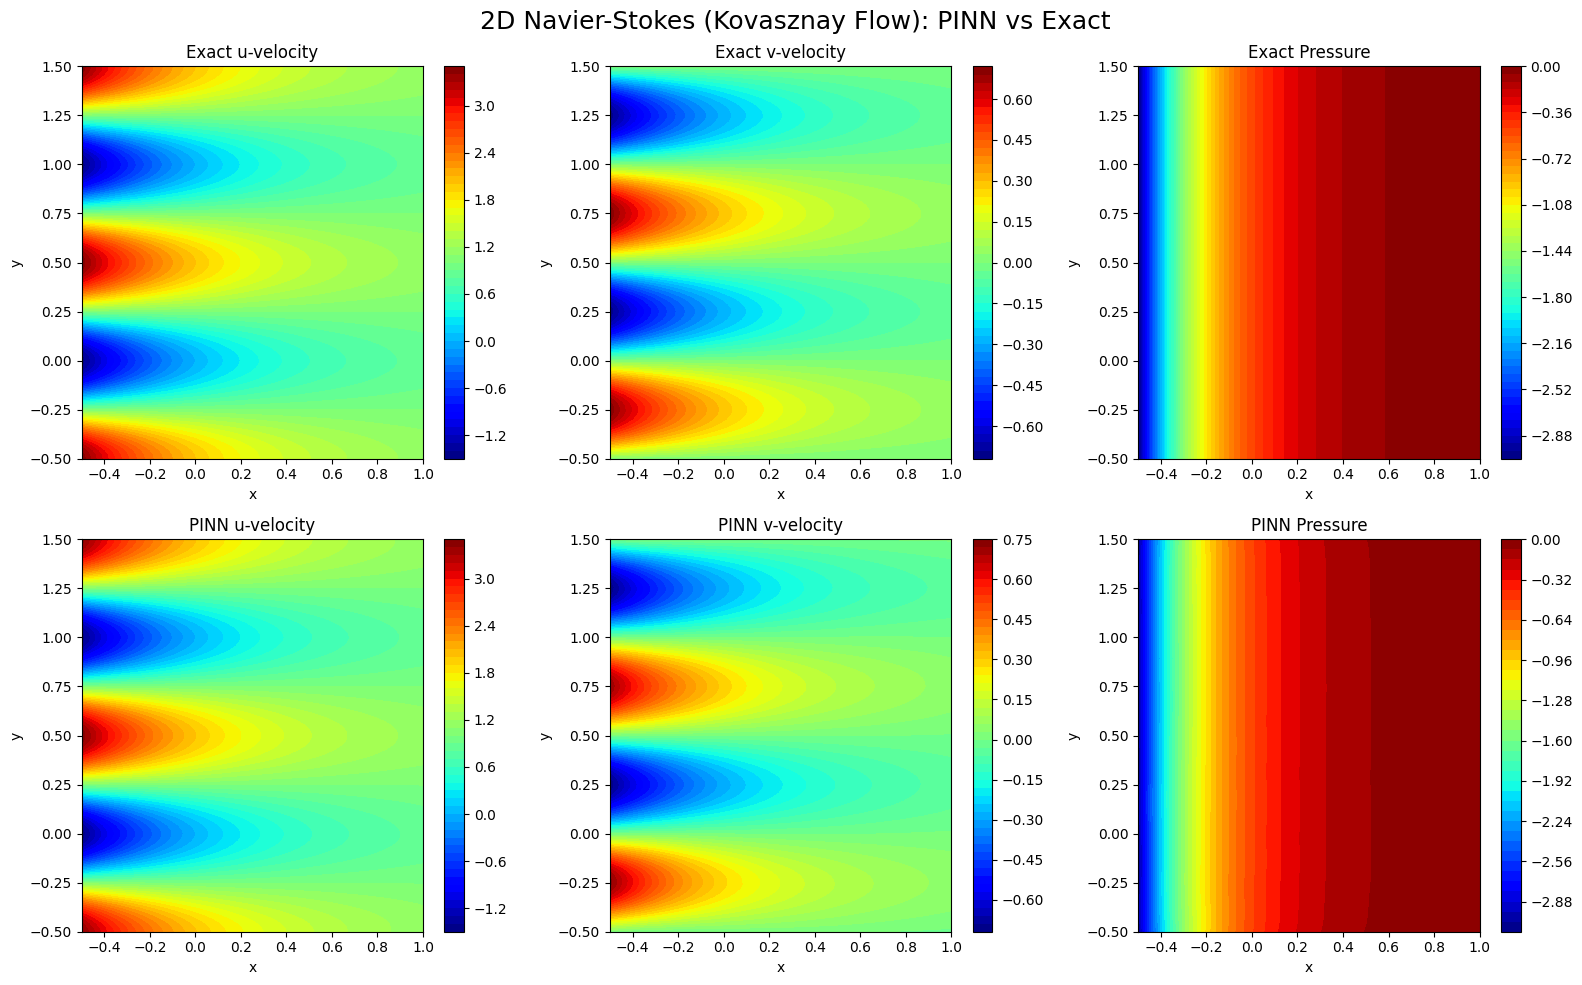

In [10]:
# ==========================================
# 7. Evaluation & Plotting
# ==========================================
# Create a 2D meshgrid for plotting
x_grid = np.linspace(x_min, x_max, 100)
y_grid = np.linspace(y_min, y_max, 100)
X, Y = np.meshgrid(x_grid, y_grid)

X_flat = X.flatten()[:, None]
Y_flat = Y.flatten()[:, None]

X_pt = torch.tensor(X_flat, dtype=torch.float32, device=device)
Y_pt = torch.tensor(Y_flat, dtype=torch.float32, device=device)

with torch.no_grad():
    u_pred, v_pred, p_pred = model(X_pt, Y_pt)
    u_pred = u_pred.cpu().numpy().reshape(100, 100)
    v_pred = v_pred.cpu().numpy().reshape(100, 100)
    p_pred = p_pred.cpu().numpy().reshape(100, 100)

u_exact, v_exact, p_exact = exact_kovasznay(X, Y)

# Plotting Comparison
fig, axs = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('2D Navier-Stokes (Kovasznay Flow): PINN vs Exact', fontsize=18)

# Exact Plots
c1 = axs[0, 0].contourf(X, Y, u_exact, 50, cmap='jet'); fig.colorbar(c1, ax=axs[0,0])
axs[0, 0].set_title('Exact u-velocity'); axs[0, 0].set_xlabel('x'); axs[0, 0].set_ylabel('y')

c2 = axs[0, 1].contourf(X, Y, v_exact, 50, cmap='jet'); fig.colorbar(c2, ax=axs[0,1])
axs[0, 1].set_title('Exact v-velocity'); axs[0, 1].set_xlabel('x'); axs[0, 1].set_ylabel('y')

c3 = axs[0, 2].contourf(X, Y, p_exact, 50, cmap='jet'); fig.colorbar(c3, ax=axs[0,2])
axs[0, 2].set_title('Exact Pressure'); axs[0, 2].set_xlabel('x'); axs[0, 2].set_ylabel('y')

# PINN Plots
c4 = axs[1, 0].contourf(X, Y, u_pred, 50, cmap='jet'); fig.colorbar(c4, ax=axs[1,0])
axs[1, 0].set_title('PINN u-velocity'); axs[1, 0].set_xlabel('x'); axs[1, 0].set_ylabel('y')

c5 = axs[1, 1].contourf(X, Y, v_pred, 50, cmap='jet'); fig.colorbar(c5, ax=axs[1,1])
axs[1, 1].set_title('PINN v-velocity'); axs[1, 1].set_xlabel('x'); axs[1, 1].set_ylabel('y')

c6 = axs[1, 2].contourf(X, Y, p_pred, 50, cmap='jet'); fig.colorbar(c6, ax=axs[1,2])
axs[1, 2].set_title('PINN Pressure'); axs[1, 2].set_xlabel('x'); axs[1, 2].set_ylabel('y')

plt.tight_layout()
plt.savefig('kovasznay_results.png', dpi=300, bbox_inches='tight')
plt.show()